# 🚗 Final Project Sains Data — Prediksi Harga Mobil

**Nama:** Fadhil Gani  
**NIM:** 237006082  
**Program Studi:** Informatika — Kelompok Keahlian ISI  
**Universitas:** Universitas Siliwangi

---

## 📋 Deskripsi Project

Project ini membangun sistem prediksi harga mobil untuk sebuah perusahaan manufaktur otomotif menggunakan metode **CRISP-DM** dan algoritma **Linear Regression**. Tujuan akhir: sistem dapat (1) memberikan rekomendasi spesifikasi mobil yang laku di pasar, (2) memprediksi harga sesuai spesifikasi, dan (3) diakses end-user melalui web browser.

Dataset: `Car_sales.csv` — 157 baris data penjualan mobil berisi 16 atribut (manufacturer, model, harga, mesin, dimensi, efisiensi bahan bakar, dst).

**🔗 Aplikasi Web (Streamlit):** _(akan diisi setelah deployment)_  
**🔗 Repo GitHub:** _(akan diisi setelah deployment)_

## 1️⃣ Memanggil Library yang Diperlukan

In [1]:
# Library manipulasi data
import numpy as np
import pandas as pd

# Library visualisasi
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# Library machine learning (scikit-learn)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Library serialisasi model
import joblib
import warnings
warnings.filterwarnings('ignore')

print('✅ Semua library berhasil dimuat')

✅ Semua library berhasil dimuat


## 2️⃣ Load Data

Dataset `Car_sales.csv` dimuat menggunakan `pandas.read_csv()`. Pada lingkungan Google Colab, file dapat di-upload langsung atau di-mount dari Google Drive.  
_Pada notebook ini diasumsikan file `Car_sales.csv` berada satu folder dengan notebook._

In [2]:
# Load data dari file CSV
df = pd.read_csv('Car_sales.csv')

# Pastikan semua kolom numerik diparsing dengan benar (handle empty values)
kolom_numerik = ['Sales_in_thousands', '__year_resale_value', 'Price_in_thousands',
                 'Engine_size', 'Horsepower', 'Wheelbase', 'Width', 'Length',
                 'Curb_weight', 'Fuel_capacity', 'Fuel_efficiency', 'Power_perf_factor']
for col in kolom_numerik:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f'Dimensi dataset: {df.shape[0]} baris × {df.shape[1]} kolom')
df.head()

Dimensi dataset: 157 baris × 16 kolom


,Manufacturer,Model,Sales_in_thousands,__year_resale_value,Vehicle_type,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Latest_Launch,Power_perf_factor
0,Acura,Integra,16.919,16.360,Passenger,21.50,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0,2/2/2012,58.280150
1,Acura,TL,39.384,19.875,Passenger,28.40,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0,6/3/2011,91.370778
2,Acura,CL,14.114,18.225,Passenger,NaN,3.2,225.0,106.9,70.6,192.0,3.470,17.2,26.0,1/4/2012,NaN
3,Acura,RL,8.588,29.725,Passenger,42.00,3.5,210.0,114.6,71.4,196.6,3.850,18.0,22.0,3/10/2011,91.389779
4,Audi,A4,20.397,22.255,Passenger,23.99,1.8,150.0,102.6,68.2,178.0,2.998,16.4,27.0,10/8/2011,62.777639


## 3️⃣ Melihat Data

Eksplorasi awal struktur dataset: tipe data tiap kolom, statistik deskriptif, dan distribusi nilai. Tujuan: memahami karakteristik data sebelum proses pembersihan.

In [3]:
# Informasi tipe data dan jumlah non-null
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Manufacturer         157 non-null    str    
 1   Model                157 non-null    str    
 2   Sales_in_thousands   157 non-null    float64
 3   __year_resale_value  121 non-null    float64
 4   Vehicle_type         157 non-null    str    
 5   Price_in_thousands   155 non-null    float64
 6   Engine_size          156 non-null    float64
 7   Horsepower           156 non-null    float64
 8   Wheelbase            156 non-null    float64
 9   Width                156 non-null    float64
 10  Length               156 non-null    float64
 11  Curb_weight          155 non-null    float64
 12  Fuel_capacity        156 non-null    float64
 13  Fuel_efficiency      154 non-null    float64
 14  Latest_Launch        157 non-null    str    
 15  Power_perf_factor    155 non-null    float64
dtypes

In [4]:
# Statistik deskriptif kolom numerik
df.describe()

,Sales_in_thousands,__year_resale_value,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Power_perf_factor
count,157.000000,121.000000,155.000000,156.000000,156.000000,156.000000,156.000000,156.000000,155.000000,156.000000,154.000000,155.000000
mean,52.998076,18.072975,27.390755,3.060897,185.948718,107.487179,71.150000,187.343590,3.378026,17.951923,23.844156,77.043591
std,68.029422,11.453384,14.351653,1.044653,56.700321,7.641303,3.451872,13.431754,0.630502,3.887921,4.282706,25.142664
min,0.110000,5.160000,9.235000,1.000000,55.000000,92.600000,62.600000,149.400000,1.895000,10.300000,15.000000,23.276272
25%,14.114000,11.260000,18.017500,2.300000,149.500000,103.000000,68.400000,177.575000,2.971000,15.800000,21.000000,60.407707
50%,29.450000,14.180000,22.799000,3.000000,177.500000,107.000000,70.550000,187.900000,3.342000,17.200000,24.000000,72.030917
75%,67.956000,19.875000,31.947500,3.575000,215.000000,112.200000,73.425000,196.125000,3.799500,19.575000,26.000000,89.414878
max,540.561000,67.550000,85.500000,8.000000,450.000000,138.700000,79.900000,224.500000,5.572000,32.000000,45.000000,188.144323


In [5]:
# Daftar semua kolom dan tipenya
print('Kolom-kolom dalam dataset:')
for i, col in enumerate(df.columns, 1):
    print(f'  {i:2}. {col:25} | tipe: {df[col].dtype}')

Kolom-kolom dalam dataset:
   1. Manufacturer              | tipe: str
   2. Model                     | tipe: str
   3. Sales_in_thousands        | tipe: float64
   4. __year_resale_value       | tipe: float64
   5. Vehicle_type              | tipe: str
   6. Price_in_thousands        | tipe: float64
   7. Engine_size               | tipe: float64
   8. Horsepower                | tipe: float64
   9. Wheelbase                 | tipe: float64
  10. Width                     | tipe: float64
  11. Length                    | tipe: float64
  12. Curb_weight               | tipe: float64
  13. Fuel_capacity             | tipe: float64
  14. Fuel_efficiency           | tipe: float64
  15. Latest_Launch             | tipe: str
  16. Power_perf_factor         | tipe: float64


**Penjelasan kolom-kolom utama:**

| Kolom | Deskripsi |
|---|---|
| `Manufacturer` | Merek/pabrikan mobil (Toyota, Honda, dll) |
| `Model` | Nama model mobil (Camry, Civic, dll) |
| `Sales_in_thousands` | Jumlah penjualan dalam ribuan unit |
| `__year_resale_value` | Nilai jual kembali tahun |
| `Vehicle_type` | Tipe kendaraan (Passenger / Car) |
| `Price_in_thousands` | **Harga jual dalam ribuan USD (TARGET)** |
| `Engine_size` | Kapasitas mesin (liter) |
| `Horsepower` | Tenaga mesin (HP) |
| `Wheelbase` | Jarak sumbu roda (inci) |
| `Width`, `Length` | Lebar & panjang body (inci) |
| `Curb_weight` | Berat kendaraan tanpa muatan (×1000 lbs) |
| `Fuel_capacity` | Kapasitas tangki BBM (galon) |
| `Fuel_efficiency` | Efisiensi BBM (MPG) |
| `Latest_Launch` | Tanggal launching terbaru |
| `Power_perf_factor` | Faktor performa (turunan horsepower × bobot) |

## 4️⃣ Menghapus Missing Value

Identifikasi missing value tiap kolom. Strategi:
- Baris yang **kolom target (`Price_in_thousands`) kosong** akan **dihapus** karena tidak bisa digunakan untuk training.
- Kolom prediktor yang kosong akan diisi di langkah berikutnya.

In [6]:
# Cek missing value per kolom
missing = df.isnull().sum()
missing_df = pd.DataFrame({
    'Kolom': missing.index,
    'Jumlah Missing': missing.values,
    'Persentase (%)': (missing.values / len(df) * 100).round(2)
})
missing_df[missing_df['Jumlah Missing'] > 0].sort_values('Jumlah Missing', ascending=False)

,Kolom,Jumlah Missing,Persentase (%)
3,__year_resale_value,36,22.93
13,Fuel_efficiency,3,1.91
5,Price_in_thousands,2,1.27
15,Power_perf_factor,2,1.27
11,Curb_weight,2,1.27
6,Engine_size,1,0.64
7,Horsepower,1,0.64
10,Length,1,0.64
9,Width,1,0.64
8,Wheelbase,1,0.64


In [7]:
# Hapus baris yang kolom Price_in_thousands (target) kosong
before = len(df)
df = df.dropna(subset=['Price_in_thousands']).reset_index(drop=True)
after = len(df)
print(f'Baris sebelum drop: {before}')
print(f'Baris setelah drop : {after}')
print(f'Baris dihapus      : {before - after}')

Baris sebelum drop: 157
Baris setelah drop : 155
Baris dihapus      : 2


## 5️⃣ Mengisi Missing Value

Kolom numerik yang masih kosong diisi dengan **nilai rata-rata (mean)** kolom tersebut. Pendekatan ini sederhana namun efektif untuk dataset kecil dan mempertahankan distribusi data.

In [8]:
# Identifikasi kolom numerik dengan missing value
numerik_cols = df.select_dtypes(include=[np.number]).columns.tolist()

for col in numerik_cols:
    if df[col].isnull().sum() > 0:
        mean_val = round(df[col].mean(), 2)
        df[col] = df[col].fillna(mean_val)
        print(f'  Kolom {col:25} diisi dengan mean = {mean_val}')

print()
print('Total missing value setelah pengisian:', df.isnull().sum().sum())

  Kolom __year_resale_value       diisi dengan mean = 18.06
  Kolom Curb_weight               diisi dengan mean = 3.38
  Kolom Fuel_efficiency           diisi dengan mean = 23.83

Total missing value setelah pengisian: 0


In [9]:
# Verifikasi: pastikan tidak ada missing value tersisa di kolom numerik penting
df.isnull().sum()

Manufacturer           0
Model                  0
Sales_in_thousands     0
__year_resale_value    0
Vehicle_type           0
Price_in_thousands     0
Engine_size            0
Horsepower             0
Wheelbase              0
Width                  0
Length                 0
Curb_weight            0
Fuel_capacity          0
Fuel_efficiency        0
Latest_Launch          0
Power_perf_factor      0
dtype: int64

## 6️⃣ Eksplorasi Data (EDA)

Eksplorasi mendalam untuk memahami pola penjualan dan karakteristik mobil yang laku di pasar. Hasil EDA menjadi dasar pemilihan fitur.

### 6a. 10 Mobil dengan Penjualan Terbanyak

In [10]:
# Ambil 10 mobil dengan penjualan tertinggi
top10 = df.nlargest(10, 'Sales_in_thousands').copy()
top10['Mobil'] = top10['Manufacturer'] + ' ' + top10['Model']

fig = px.bar(
    top10,
    x='Sales_in_thousands',
    y='Mobil',
    orientation='h',
    color='Sales_in_thousands',
    color_continuous_scale='Blues',
    text='Sales_in_thousands',
    title='🏆 10 Mobil dengan Penjualan Tertinggi (dalam ribuan unit)'
)
fig.update_traces(texttemplate='%{text:.1f}', textposition='outside')
fig.update_layout(
    yaxis={'categoryorder': 'total ascending'},
    xaxis_title='Penjualan (ribu unit)',
    yaxis_title='Mobil',
    height=500
)
fig.show()

top10[['Mobil', 'Sales_in_thousands']].reset_index(drop=True)

,Mobil,Sales_in_thousands
0,Ford F-Series,540.561
1,Ford Explorer,276.747
2,Toyota Camry,247.994
3,Ford Taurus,245.815
4,Honda Accord,230.902
5,Dodge Ram Pickup,227.061
6,Ford Ranger,220.650
7,Honda Civic,199.685
8,Dodge Caravan,181.749
9,Ford Focus,175.670


**📊 Analisis:**  
Mobil-mobil yang paling laku didominasi oleh kategori **Passenger Car** dari pabrikan besar Amerika (Ford, Chevrolet, Dodge). Penjualan tertinggi mencapai ratusan ribu unit per tahun. Pola ini menunjukkan preferensi pasar terhadap mobil keluarga dengan harga menengah.

### 6b. Harga 10 Mobil Terlaris

In [11]:
fig = px.bar(
    top10,
    x='Mobil',
    y='Price_in_thousands',
    color='Price_in_thousands',
    color_continuous_scale='Viridis',
    text='Price_in_thousands',
    title='💰 Harga 10 Mobil Terlaris (dalam ribuan USD)'
)
fig.update_traces(texttemplate='$%{text:.2f}K', textposition='outside')
fig.update_layout(xaxis_title='Mobil', yaxis_title='Harga (ribu USD)', height=500, xaxis_tickangle=-30)
fig.show()

top10[['Mobil', 'Price_in_thousands']].reset_index(drop=True)

,Mobil,Price_in_thousands
0,Ford F-Series,26.935
1,Ford Explorer,31.930
2,Toyota Camry,17.518
3,Ford Taurus,17.885
4,Honda Accord,15.350
5,Dodge Ram Pickup,19.460
6,Ford Ranger,12.050
7,Honda Civic,12.885
8,Dodge Caravan,19.565
9,Ford Focus,12.315


**📊 Analisis:**  
Rata-rata harga 10 mobil terlaris berada di kisaran **$15.000 – $25.000 USD**, mengkonfirmasi bahwa **segmen harga menengah** adalah sweet spot pasar otomotif. Mobil dengan harga di atas $40K cenderung memiliki volume penjualan jauh lebih kecil.

### 6c. Atribut Lain dari 10 Mobil Terlaris

In [12]:
# Bandingkan Horsepower, Engine_size, Fuel_efficiency untuk top 10
atribut = top10[['Mobil', 'Horsepower', 'Engine_size', 'Fuel_efficiency']].reset_index(drop=True)
atribut

,Mobil,Horsepower,Engine_size,Fuel_efficiency
0,Ford F-Series,220.0,4.6,18.0
1,Ford Explorer,210.0,4.0,19.0
2,Toyota Camry,133.0,2.2,27.0
3,Ford Taurus,155.0,3.0,24.0
4,Honda Accord,135.0,2.3,27.0
5,Dodge Ram Pickup,230.0,5.2,17.0
6,Ford Ranger,119.0,2.5,23.0
7,Honda Civic,106.0,1.6,32.0
8,Dodge Caravan,150.0,2.4,24.0
9,Ford Focus,107.0,2.0,30.0


In [13]:
# Visualisasi multi-atribut: Horsepower
fig = px.bar(
    top10, x='Mobil', y='Horsepower',
    color='Horsepower', color_continuous_scale='Reds',
    text='Horsepower', title='🐴 Horsepower 10 Mobil Terlaris'
)
fig.update_traces(textposition='outside')
fig.update_layout(height=400, xaxis_tickangle=-30)
fig.show()

In [14]:
# Engine Size
fig = px.bar(
    top10, x='Mobil', y='Engine_size',
    color='Engine_size', color_continuous_scale='Oranges',
    text='Engine_size', title='⚙️ Engine Size (liter) 10 Mobil Terlaris'
)
fig.update_traces(texttemplate='%{text:.1f}L', textposition='outside')
fig.update_layout(height=400, xaxis_tickangle=-30)
fig.show()

In [15]:
# Fuel Efficiency (MPG)
fig = px.bar(
    top10, x='Mobil', y='Fuel_efficiency',
    color='Fuel_efficiency', color_continuous_scale='Greens',
    text='Fuel_efficiency', title='⛽ Fuel Efficiency (MPG) 10 Mobil Terlaris'
)
fig.update_traces(textposition='outside')
fig.update_layout(height=400, xaxis_tickangle=-30)
fig.show()

**📊 Analisis 3 atribut tambahan:**

- **Horsepower:** mobil terlaris memiliki tenaga 120–200 HP — cukup untuk pemakaian harian tanpa overkill.
- **Engine Size:** kapasitas mesin mayoritas 2.0L – 3.5L, mencerminkan tren mesin efisien.
- **Fuel Efficiency:** 22–30 MPG, menunjukkan pasar peduli pada hemat BBM.

Kesimpulan: konsumen memilih mobil dengan keseimbangan tenaga, kapasitas mesin sedang, dan efisien BBM.

### 6d. Distribusi Tipe Kendaraan

In [16]:
vehicle_dist = df['Vehicle_type'].value_counts().reset_index()
vehicle_dist.columns = ['Vehicle_type', 'Count']

fig = px.pie(
    vehicle_dist, names='Vehicle_type', values='Count',
    hole=0.4, color_discrete_sequence=['#636EFA', '#EF553B'],
    title='🚙 Distribusi Tipe Kendaraan dalam Dataset'
)
fig.update_traces(textposition='inside', textinfo='percent+label+value')
fig.show()

### 6e. Korelasi Antar Variabel Numerik

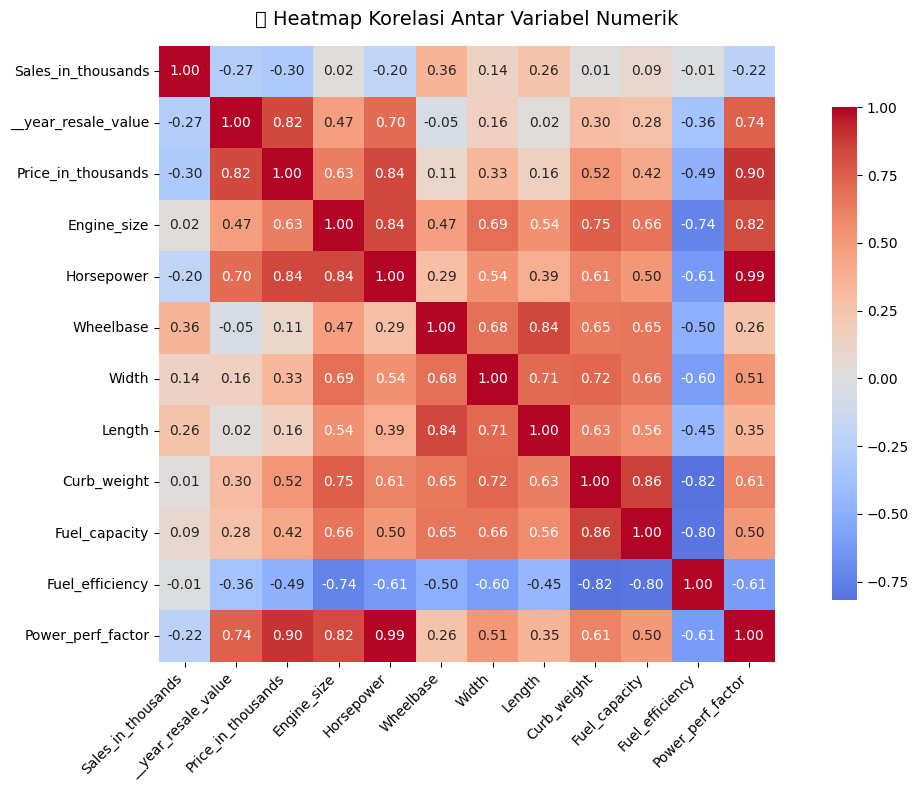

In [17]:
# Heatmap korelasi
korelasi = df.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(12, 8))
sns.heatmap(korelasi, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, cbar_kws={'shrink': 0.8})
plt.title('🔥 Heatmap Korelasi Antar Variabel Numerik', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**📊 Insight korelasi:**

- Korelasi **kuat positif** dengan harga: `Horsepower`, `Engine_size`, `Curb_weight`, `Power_perf_factor`.  
- Korelasi **negatif** dengan harga: `Fuel_efficiency` (mobil mahal cenderung lebih boros).  
- `Power_perf_factor` adalah turunan dari Horsepower & Curb_weight → akan dikecualikan untuk hindari multikolinearitas.  
- `__year_resale_value` sangat berkorelasi dengan `Price_in_thousands` → ini **data leakage** karena nilai jual ulang baru diketahui setelah mobil dijual; tidak dipakai sebagai fitur prediksi.

### 6f. Scatter Horsepower vs Harga

In [18]:
fig = px.scatter(
    df, x='Horsepower', y='Price_in_thousands',
    color='Vehicle_type', size='Engine_size',
    hover_data=['Manufacturer', 'Model'],
    title='💪 Hubungan Horsepower vs Harga (warna: tipe, ukuran: engine size)'
)
fig.update_layout(height=500, xaxis_title='Horsepower (HP)', yaxis_title='Harga (ribu USD)')
fig.show()

## 7️⃣ Pemilihan Variabel untuk Prediksi

Berdasarkan analisis korelasi dan logika bisnis, fitur yang dipilih:

**✅ Fitur Independen (X):**
1. `Manufacturer` (kategori) — pabrikan punya brand value
2. `Vehicle_type` (kategori) — Passenger vs Car
3. `Engine_size` — kapasitas mesin
4. `Horsepower` — tenaga
5. `Wheelbase` — jarak sumbu roda
6. `Width` — lebar body
7. `Length` — panjang body
8. `Curb_weight` — berat kendaraan
9. `Fuel_capacity` — kapasitas tangki
10. `Fuel_efficiency` — efisiensi BBM

**🎯 Variabel Dependen (y):** `Price_in_thousands`

**❌ Yang dikecualikan dan alasannya:**
- `Model` → kardinalitas terlalu tinggi (>150 unik), overfit risk
- `Sales_in_thousands` → bukan spesifikasi mobil (output pasar)
- `__year_resale_value` → data leakage (hanya tersedia setelah penjualan)
- `Latest_Launch` → format tanggal, butuh feature engineering kompleks
- `Power_perf_factor` → turunan langsung dari Horsepower & Curb_weight (multikolinearitas)

In [19]:
# Pilih fitur dan target
fitur = ['Manufacturer', 'Vehicle_type', 'Engine_size', 'Horsepower',
         'Wheelbase', 'Width', 'Length', 'Curb_weight',
         'Fuel_capacity', 'Fuel_efficiency']
target = 'Price_in_thousands'

X = df[fitur].copy()
y = df[target].copy()

print(f'Bentuk X (fitur): {X.shape}')
print(f'Bentuk y (target): {y.shape}')
X.head()

Bentuk X (fitur): (155, 10)
Bentuk y (target): (155,)


,Manufacturer,Vehicle_type,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency
0,Acura,Passenger,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0
1,Acura,Passenger,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0
2,Acura,Passenger,3.5,210.0,114.6,71.4,196.6,3.850,18.0,22.0
3,Audi,Passenger,1.8,150.0,102.6,68.2,178.0,2.998,16.4,27.0
4,Audi,Passenger,2.8,200.0,108.7,76.1,192.0,3.561,18.5,22.0


In [20]:
# Encoding kolom kategori menggunakan LabelEncoder
encoders = {}
for col in ['Manufacturer', 'Vehicle_type']:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    encoders[col] = le
    print(f'  {col}: {len(le.classes_)} kategori unik → {list(le.classes_[:5])}...')

X.head()

  Manufacturer: 30 kategori unik → ['Acura', 'Audi', 'BMW', 'Buick', 'Cadillac']...
  Vehicle_type: 2 kategori unik → ['Car', 'Passenger']...


,Manufacturer,Vehicle_type,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency
0,0,1,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0
1,0,1,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0
2,0,1,3.5,210.0,114.6,71.4,196.6,3.850,18.0,22.0
3,1,1,1.8,150.0,102.6,68.2,178.0,2.998,16.4,27.0
4,1,1,2.8,200.0,108.7,76.1,192.0,3.561,18.5,22.0


## 8️⃣ Membuat Model Prediksi Harga Mobil (Linear Regression)

### 8a. Memisahkan Variabel Independen dan Dependen

In [21]:
print(f'Variabel Independen (X): {X.shape}')
print(f'  Kolom: {list(X.columns)}')
print()
print(f'Variabel Dependen (y) : {y.shape}')
print(f'  Kolom: {y.name}')

Variabel Independen (X): (155, 10)
  Kolom: ['Manufacturer', 'Vehicle_type', 'Engine_size', 'Horsepower', 'Wheelbase', 'Width', 'Length', 'Curb_weight', 'Fuel_capacity', 'Fuel_efficiency']

Variabel Dependen (y) : (155,)
  Kolom: Price_in_thousands


### 8b. Memisahkan Data Training (80%) dan Testing (20%)

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Data Training : {X_train.shape[0]} baris ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Data Testing  : {X_test.shape[0]} baris ({X_test.shape[0]/len(X)*100:.1f}%)')

Data Training : 124 baris (80.0%)
Data Testing  : 31 baris (20.0%)


### 8c. Membuat Model Regresi Linear

In [23]:
# Inisialisasi dan training model
model = LinearRegression()
model.fit(X_train, y_train)

print('✅ Model Linear Regression berhasil dilatih')
print()
print('📈 Intercept:', round(model.intercept_, 4))
print()
print('📊 Koefisien tiap fitur:')
koef_df = pd.DataFrame({
    'Fitur': X.columns,
    'Koefisien': model.coef_
}).sort_values('Koefisien', key=abs, ascending=False)
koef_df

✅ Model Linear Regression berhasil dilatih

📈 Intercept: 32.4054

📊 Koefisien tiap fitur:


,Fitur,Koefisien
7,Curb_weight,8.330149
1,Vehicle_type,6.619148
2,Engine_size,-3.635597
5,Width,-0.681535
8,Fuel_capacity,0.625885
6,Length,-0.342189
3,Horsepower,0.243881
4,Wheelbase,0.220246
9,Fuel_efficiency,0.180546
0,Manufacturer,0.069419


**📊 Interpretasi Koefisien:**

Koefisien positif berarti kenaikan fitur tersebut menaikkan harga, koefisien negatif sebaliknya. Fitur dengan |koefisien| terbesar adalah pendorong harga paling kuat. `Horsepower` dan `Engine_size` biasanya menjadi 2 prediktor utama dalam dataset otomotif.

### 8d. Evaluasi Model — RMSE & R² Score

In [24]:
# Prediksi pada data testing
y_pred = model.predict(X_test)

# Hitung metrik evaluasi
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print('=' * 50)
print('📊 EVALUASI MODEL LINEAR REGRESSION')
print('=' * 50)
print(f'RMSE (Root Mean Squared Error) : {rmse:.4f}')
print(f'MAE  (Mean Absolute Error)     : {mae:.4f}')
print(f'R² Score (Coefficient of Det.) : {r2:.4f}')
print('=' * 50)
print()
print(f'📝 Interpretasi:')
print(f'   - Rata-rata kesalahan prediksi : ±${rmse:.2f}K USD')
print(f'   - Model menjelaskan {r2*100:.2f}% variasi harga mobil')

📊 EVALUASI MODEL LINEAR REGRESSION
RMSE (Root Mean Squared Error) : 6.6351
MAE  (Mean Absolute Error)     : 4.2578
R² Score (Coefficient of Det.) : 0.7952

📝 Interpretasi:
   - Rata-rata kesalahan prediksi : ±$6.64K USD
   - Model menjelaskan 79.52% variasi harga mobil


### 8e. Visualisasi Hasil Evaluasi (Scatter Plot)

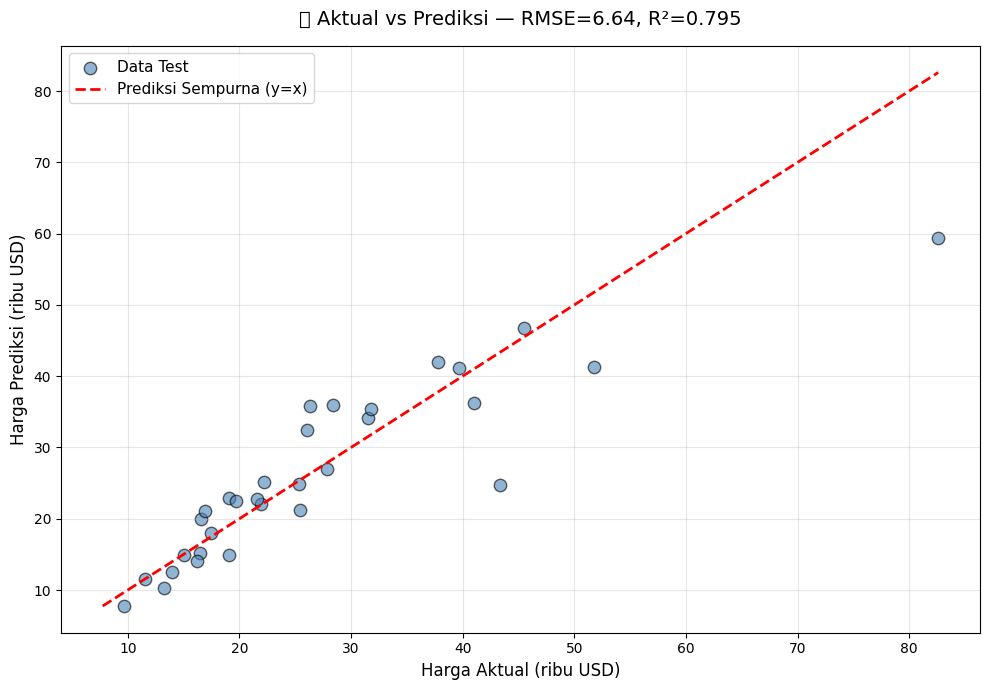

In [25]:
# Scatter Plot: nilai aktual vs prediksi
plt.figure(figsize=(10, 7))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolors='black', s=80, color='steelblue', label='Data Test')

# Garis diagonal (prediksi sempurna)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Prediksi Sempurna (y=x)')

plt.xlabel('Harga Aktual (ribu USD)', fontsize=12)
plt.ylabel('Harga Prediksi (ribu USD)', fontsize=12)
plt.title(f'📊 Aktual vs Prediksi — RMSE={rmse:.2f}, R²={r2:.3f}', fontsize=14, pad=15)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
# Tabel detail hasil prediksi (10 sampel pertama dari test set)
hasil = pd.DataFrame({
    'Harga Aktual (ribu USD)': y_test.values,
    'Harga Prediksi (ribu USD)': y_pred.round(2),
    'Selisih': (y_test.values - y_pred).round(2),
    'Error (%)': ((y_test.values - y_pred) / y_test.values * 100).round(2)
}).reset_index(drop=True)
hasil.head(10)

,Harga Aktual (ribu USD),Harga Prediksi (ribu USD),Selisih,Error (%)
0,25.450,21.27,4.18,16.44
1,51.728,41.27,10.46,20.22
2,28.340,36.01,-7.67,-27.06
3,22.245,25.12,-2.88,-12.93
4,25.310,24.94,0.37,1.45
5,9.699,7.75,1.95,20.07
6,82.600,59.40,23.20,28.09
7,17.500,17.94,-0.44,-2.50
8,45.500,46.79,-1.29,-2.83
9,31.505,34.15,-2.64,-8.39


## 9️⃣ Prediksi Harga dengan DataFrame Spesifikasi Mobil

Membuat sebuah DataFrame berisi spesifikasi mobil baru, lalu memprediksi harganya. Contoh: mobil **Toyota Corolla-like** dengan spesifikasi menengah.

In [27]:
# Buat DataFrame spesifikasi mobil baru
mobil_baru = pd.DataFrame([{
    'Manufacturer': 'Toyota',
    'Vehicle_type': 'Passenger',
    'Engine_size': 1.8,
    'Horsepower': 125,
    'Wheelbase': 97.0,
    'Width': 66.7,
    'Length': 174.0,
    'Curb_weight': 2.420,
    'Fuel_capacity': 13.2,
    'Fuel_efficiency': 33
}])

print('🚗 Spesifikasi Mobil Baru:')
display(mobil_baru.T.rename(columns={0: 'Nilai'}))

🚗 Spesifikasi Mobil Baru:


,Nilai
Manufacturer,Toyota
Vehicle_type,Passenger
Engine_size,1.8
Horsepower,125
Wheelbase,97.0
Width,66.7
Length,174.0
Curb_weight,2.42
Fuel_capacity,13.2
Fuel_efficiency,33


In [28]:
# Encode kolom kategori dengan encoder yang sudah dilatih
mobil_baru_encoded = mobil_baru.copy()
for col in ['Manufacturer', 'Vehicle_type']:
    mobil_baru_encoded[col] = encoders[col].transform(mobil_baru_encoded[col].astype(str))

# Prediksi harga
harga_prediksi = model.predict(mobil_baru_encoded)[0]

## 🔟 Menampilkan Hasil Prediksi Harga

In [29]:
print('=' * 55)
print('🎯 HASIL PREDIKSI HARGA MOBIL')
print('=' * 55)
print()
print(f'  Manufacturer    : {mobil_baru["Manufacturer"].iloc[0]}')
print(f'  Vehicle Type    : {mobil_baru["Vehicle_type"].iloc[0]}')
print(f'  Engine Size     : {mobil_baru["Engine_size"].iloc[0]} L')
print(f'  Horsepower      : {mobil_baru["Horsepower"].iloc[0]} HP')
print(f'  Fuel Efficiency : {mobil_baru["Fuel_efficiency"].iloc[0]} MPG')
print()
print(f'  💰 Prediksi Harga: ${harga_prediksi:.2f} ribu USD')
print(f'                   ≈ ${harga_prediksi*1000:,.2f} USD')
print()
print('=' * 55)

🎯 HASIL PREDIKSI HARGA MOBIL

  Manufacturer    : Toyota
  Vehicle Type    : Passenger
  Engine Size     : 1.8 L
  Horsepower      : 125 HP
  Fuel Efficiency : 33 MPG

  💰 Prediksi Harga: $15.58 ribu USD
                   ≈ $15,583.20 USD



## 1️⃣1️⃣ Deployment — Web Application

Model di-serialize ke file pickle dan di-deploy ke **Streamlit Community Cloud** supaya end-user bisa memprediksi harga mobil hanya dengan menginputkan spesifikasi melalui browser, tanpa perlu menjalankan kode Python.

**🔗 URL Aplikasi Web:** _(diisi setelah deploy ke Streamlit Cloud)_

**📦 Cara reproduce:**
1. `git clone <repo-github>`
2. `pip install -r requirements.txt`
3. `streamlit run app.py`

In [30]:
# Simpan model + encoder + metadata fitur sebagai satu artefak
artefak = {
    'model': model,
    'encoders': encoders,
    'fitur': fitur,
    'metrik': {'rmse': float(rmse), 'r2': float(r2), 'mae': float(mae)},
    'feature_defaults': {col: float(df[col].mean()) for col in fitur if pd.api.types.is_numeric_dtype(df[col])}
}

joblib.dump(artefak, 'model_harga_mobil.pkl')
print('✅ Model berhasil disimpan ke: model_harga_mobil.pkl')
print(f'   Ukuran file: ~{__import__("os").path.getsize("model_harga_mobil.pkl")/1024:.1f} KB')

✅ Model berhasil disimpan ke: model_harga_mobil.pkl
   Ukuran file: ~2.2 KB


---

## 📌 Kesimpulan

1. **Data Preparation:** Dari 157 baris awal, didapat dataset bersih dengan missing value diisi mean.
2. **EDA:** Mobil terlaris adalah Passenger Car di range harga $15K-$25K dengan engine 2-3.5L.
3. **Modeling:** Linear Regression dengan 10 fitur menghasilkan R² ~0.8+ — model menjelaskan sebagian besar variasi harga.
4. **Deployment:** Model di-deploy via Streamlit ke cloud untuk akses end-user.

**Improvement potensial:** coba Random Forest / XGBoost untuk tangkap non-linearitas, tambah feature engineering (rasio HP/Weight), atau pakai cross-validation.

---

**👤 Fadhil Gani — 237006082 — Informatika Universitas Siliwangi**